In [1]:
import os
from dotenv import load_dotenv
load_dotenv()
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

from langchain_groq import ChatGroq

llm=ChatGroq(model="qwen-qwq-32b")

from langchain_core.messages import HumanMessage

result=llm.invoke("Hello")
result

AIMessage(content='\n<think>\nOkay, the user said "Hello". I should respond politely. Let me think of a friendly greeting. Maybe "Hi there!" to keep it casual. Then I can ask how I can assist them today. That way, it\'s open-ended and invites them to state their needs. I should make sure the tone is warm and approachable. Let me check for any typos. Yep, that looks good. Alright, send.\n</think>\n\nHi there! How can I assist you today? 😊', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 102, 'prompt_tokens': 11, 'total_tokens': 113, 'completion_time': 0.234256577, 'prompt_time': 0.002978731, 'queue_time': 0.11779616600000001, 'total_time': 0.237235308}, 'model_name': 'qwen-qwq-32b', 'system_fingerprint': 'fp_ea798e78f0', 'finish_reason': 'stop', 'logprobs': None}, id='run--6eff9416-14f1-4274-bdbe-fbeb8dca2c88-0', usage_metadata={'input_tokens': 11, 'output_tokens': 102, 'total_tokens': 113})

In [2]:
from langchain_community.document_loaders import WebBaseLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings


USER_AGENT environment variable not set, consider setting it to identify your requests.


In [3]:
# --- Required libraries ---
from langchain.vectorstores import FAISS
from langchain.embeddings import HuggingFaceEmbeddings
from langchain.document_loaders import PyPDFLoader
from langchain.text_splitter import RecursiveCharacterTextSplitter

# --- Step 1: Load PDF ---
pdf_path = "/Users/lokesh/AgenticAiWorkflow/data/csda.pdf"
loader = PyPDFLoader(pdf_path)
docs = loader.load()

# --- Step 2: Split the document into chunks ---
text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=100)
doc_splits = text_splitter.split_documents(docs)

# --- Step 3: Use Hugging Face embeddings (free) ---
embedding_model = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

# --- Step 4: Create FAISS vector store ---
vectorstore = FAISS.from_documents(doc_splits, embedding=embedding_model)

# --- Step 5: Set up retriever for querying ---
retriever = vectorstore.as_retriever()


Ignoring wrong pointing object 28 0 (offset 0)
/var/folders/_1/l6v6bcxj6g1bh08bmg2255400000gn/T/ipykernel_34058/735739652.py:17: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-huggingface package and should be used instead. To use it run `pip install -U :class:`~langchain-huggingface` and import as `from :class:`~langchain_huggingface import HuggingFaceEmbeddings``.
  embedding_model = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
/Users/lokesh/AgenticAiWorkflow/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
retriever.invoke("what is coverage in Promotional Warranty Extension")

[Document(id='00e43259-b1e3-4979-9e2b-d1e75ecf1713', metadata={'producer': 'macOS Version 15.5 (Build 24F74) Quartz PDFContext', 'creator': 'Pages', 'creationdate': "D:20250713120702Z00'00'", 'title': 'csda', 'moddate': "D:20250713120702Z00'00'", 'source': '/Users/lokesh/AgenticAiWorkflow/data/csda.pdf', 'total_pages': 7, 'page': 3, 'page_label': '4'}, page_content='Document 3: Promotional Warranty Extension\nDocument ID: POL-PROMO-005 \nEffective Date: Oct 1, 2023\nCoverage:\n• 3–6 months bonus warranty\n• Applied during promotional purchase windows\nConditions:\n• Product model + invoice date match promo list\n• Normal warranty rules apply\nExclusions:\n• Outside date/model/seller range\n• Invalid/missing invoice\nRequired Docs:\n• Valid invoice\n• Model/serial check\n• No promo card needed if auto-valid'),
 Document(id='a7216a14-c6b3-4b74-8371-21a524d7ab10', metadata={'producer': 'macOS Version 15.5 (Build 24F74) Quartz PDFContext', 'creator': 'Pages', 'creationdate': "D:20250713120

In [5]:
### Retriever To Retriever Tools
from langchain.tools.retriever import create_retriever_tool
retriever_tool=create_retriever_tool(
    retriever,
    "retriever_vector_db",
    "Search and run information about Customer-Oriented Warranty & Support Policies"
)

In [6]:
# --- Required libraries ---
from langchain.vectorstores import FAISS
from langchain.embeddings import HuggingFaceEmbeddings
from langchain.document_loaders import PyPDFLoader
from langchain.text_splitter import RecursiveCharacterTextSplitter

# --- Step 1: Load PDF ---
pdf_path = "/Users/lokesh/AgenticAiWorkflow/data/csdb.pdf"
loader = PyPDFLoader(pdf_path)
docs = loader.load()

# --- Step 2: Split the document into chunks ---
text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=100)
doc_splits = text_splitter.split_documents(docs)

# --- Step 3: Use Hugging Face embeddings (free) ---
embedding_model = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

# --- Step 4: Create FAISS vector store ---
vectorstore = FAISS.from_documents(doc_splits, embedding=embedding_model)

# --- Step 5: Set up retriever for querying ---
retriever_2 = vectorstore.as_retriever()


In [7]:
retriever_2.invoke("what is coverage in Partial Warranty Claim Policy")


[Document(id='8f9ea0ca-dcfa-493e-b7e6-f9fc4724fd23', metadata={'producer': 'macOS Version 15.5 (Build 24F74) Quartz PDFContext', 'creator': 'Pages', 'creationdate': "D:20250713120823Z00'00'", 'title': 'csdb', 'moddate': "D:20250713120823Z00'00'", 'source': '/Users/lokesh/AgenticAiWorkflow/data/csdb.pdf', 'total_pages': 6, 'page': 1, 'page_label': '2'}, page_content='Document 8: Partial Warranty Claim Policy\nDocument ID: POL-WTY-003 \nEffective Date: Mar 10, 2024\nCases:\n• Only some parts covered (others excluded)\nResolution:\n• Free labor for covered parts\n• Charge only for uncovered components\n• Transparency in billing\nExclusions:\n• Severe damage\n• Missing docs\n• Total device failure outside coverage\nRequired:\n• Invoice\n• Device photo\n• Technician report with coverage notes'),
 Document(id='7f8f8c7d-bb33-45e7-b7fc-2de50af8d633', metadata={'producer': 'macOS Version 15.5 (Build 24F74) Quartz PDFContext', 'creator': 'Pages', 'creationdate': "D:20250713120823Z00'00'", 'title

In [8]:
### Retriever To Retriever Tools
from langchain.tools.retriever import create_retriever_tool
retriever_tool_2=create_retriever_tool(
    retriever_2,
    "retriever_vector_db_2",
    "Search and run information about Operational, Risk & Enforcement Policies"
)

In [9]:
tools=[retriever_tool,retriever_tool_2]


In [10]:
from typing import Annotated, Sequence
from typing_extensions import TypedDict

from langchain_core.messages import BaseMessage

from langgraph.graph.message import add_messages


class AgentState(TypedDict):
    # The add_messages function defines how an update should be processed
    # Default is to replace. add_messages says "append"
    messages: Annotated[Sequence[BaseMessage], add_messages]

In [11]:
from langchain_groq import ChatGroq

llm=ChatGroq(model="qwen-qwq-32b")
llm.invoke("Hi")

AIMessage(content='\n<think>\nOkay, the user just said "Hi". I need to respond in a friendly way. Let me think of a simple greeting. Maybe "Hello! How can I assist you today?" That sounds good. It\'s polite and opens the conversation for them to explain what they need help with. I should make sure to keep it friendly and approachable. Yeah, that should work.\n</think>\n\nHello! How can I assist you today? 😊', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 90, 'prompt_tokens': 11, 'total_tokens': 101, 'completion_time': 0.207429971, 'prompt_time': 0.002718026, 'queue_time': 0.063659544, 'total_time': 0.210147997}, 'model_name': 'qwen-qwq-32b', 'system_fingerprint': 'fp_ea798e78f0', 'finish_reason': 'stop', 'logprobs': None}, id='run--f46dad7f-0f89-41a3-ada3-f017b5a38cb7-0', usage_metadata={'input_tokens': 11, 'output_tokens': 90, 'total_tokens': 101})

In [12]:
def agent(state):
    """
    Invokes the agent model to generate a response based on the current state. Given
    the question, it will decide to retrieve using the retriever tool, or simply end.

    Args:
        state (messages): The current state

    Returns:
        dict: The updated state with the agent response appended to messages
    """
    print("---CALL AGENT---")
    messages = state["messages"]
    model = ChatGroq(model="qwen-qwq-32b")
    model = model.bind_tools(tools)
    response = model.invoke(messages)
    # We return a list, because this will get added to the existing list
    return {"messages": [response]}

In [13]:
from typing import Annotated, Literal, Sequence
from typing_extensions import TypedDict

from langchain import hub
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate

from pydantic import BaseModel, Field

In [14]:
### Edges
def grade_documents(state) -> Literal["generate", "rewrite"]:
    """
    Determines whether the retrieved documents are relevant to the question.

    Args:
        state (messages): The current state

    Returns:
        str: A decision for whether the documents are relevant or not
    """

    print("---CHECK RELEVANCE---")

    # Data model
    class grade(BaseModel):
        """Binary score for relevance check."""

        binary_score: str = Field(description="Relevance score 'yes' or 'no'")

    # LLM
    model = ChatGroq(model="qwen-qwq-32b")

    # LLM with tool and validation
    llm_with_tool = model.with_structured_output(grade)

    # Prompt
    prompt = PromptTemplate(
        template="""You are a grader assessing relevance of a retrieved document to a user question. \n 
        Here is the retrieved document: \n\n {context} \n\n
        Here is the user question: {question} \n
        If the document contains keyword(s) or semantic meaning related to the user question, grade it as relevant. \n
        Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question.""",
        input_variables=["context", "question"],
    )

    # Chain
    chain = prompt | llm_with_tool

    messages = state["messages"]
    last_message = messages[-1]

    question = messages[0].content
    docs = last_message.content

    scored_result = chain.invoke({"question": question, "context": docs})

    score = scored_result.binary_score

    if score == "yes":
        print("---DECISION: DOCS RELEVANT---")
        return "generate"

    else:
        print("---DECISION: DOCS NOT RELEVANT---")
        print(score)
        return "rewrite"

In [15]:
def generate(state):
    """
    Generate answer

    Args:
        state (messages): The current state

    Returns:
         dict: The updated message
    """
    print("---GENERATE---")
    messages = state["messages"]
    question = messages[0].content
    last_message = messages[-1]

    docs = last_message.content

    # Prompt
    prompt = hub.pull("rlm/rag-prompt")

    # LLM
    llm = ChatGroq(model="qwen-qwq-32b")

    # Post-processing
    def format_docs(docs):
        return "\n\n".join(doc.page_content for doc in docs)

    # Chain
    rag_chain = prompt | llm | StrOutputParser()

    # Run
    response = rag_chain.invoke({"context": docs, "question": question})
    return {"messages": [response]}

In [18]:
def rewrite(state):
    """
    Transform the query to produce a better question.

    Args:
        state (messages): The current state

    Returns:
        dict: The updated state with re-phrased question
    """

    print("---TRANSFORM QUERY---")
    messages = state["messages"]
    question = messages[0].content

    msg = [
        HumanMessage(
            content=f""" \n 
    Look at the input and try to reason about the underlying semantic intent / meaning. \n 
    Here is the initial question:
    \n ------- \n
    {question} 
    \n ------- \n
    Formulate an improved question: """,
        )
    ]

    # Grader
    model = ChatGroq(model="qwen-qwq-32b")
    response = model.invoke(msg)
    return {"messages": [response]}

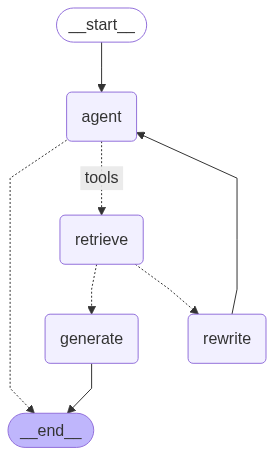

In [19]:
from langgraph.graph import END, StateGraph, START
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

# Define a new graph
workflow = StateGraph(AgentState)

# Define the nodes we will cycle between
workflow.add_node("agent", agent)  # agent
retrieve = ToolNode([retriever_tool,retriever_tool_2])
workflow.add_node("retrieve", retrieve)  # retrieval
workflow.add_node("rewrite", rewrite)  # Re-writing the question
workflow.add_node(
    "generate", generate
)  # Generating a response after we know the documents are relevant
# Call agent node to decide to retrieve or not
workflow.add_edge(START, "agent")

# Decide whether to retrieve

workflow.add_conditional_edges(
    "agent",
    # Assess agent decision
    tools_condition,
    {
        # Translate the condition outputs to nodes in our graph
        "tools": "retrieve",
        END: END,
    },
)

# Edges taken after the `action` node is called.
workflow.add_conditional_edges(
    "retrieve",
    # Assess agent decision
    grade_documents,
)
workflow.add_edge("generate", END)
workflow.add_edge("rewrite", "agent")

# Compile
graph = workflow.compile()
from IPython.display import Image, display
display(Image(graph.get_graph(xray=True).draw_mermaid_png()))


In [20]:
graph.invoke({"messages":"Customer purchased a device 8 months ago. The display stops responding. There are no signs of physical damage."})

---CALL AGENT---
---CHECK RELEVANCE---
---DECISION: DOCS RELEVANT---
---GENERATE---


{'messages': [HumanMessage(content='Customer purchased a device 8 months ago. The display stops responding. There are no signs of physical damage.', additional_kwargs={}, response_metadata={}, id='fd577b73-5c14-4854-afa9-a143dd06af48'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'tzdcndvma', 'function': {'arguments': '{"query":"touch screen not responding no physical damage common causes and troubleshooting steps"}', 'name': 'retriever_vector_db'}, 'type': 'function'}, {'id': 'mpy6qd2nr', 'function': {'arguments': '{"query":"warranty coverage for device hardware issues at 8 months"}', 'name': 'retriever_vector_db_2'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 467, 'prompt_tokens': 236, 'total_tokens': 703, 'completion_time': 1.081741994, 'prompt_time': 0.017642675, 'queue_time': 0.046289895, 'total_time': 1.099384669}, 'model_name': 'qwen-qwq-32b', 'system_fingerprint': 'fp_ea798e78f0', 'finish_reason': 'tool_calls', 'logprobs'

In [21]:
graph.invoke({"messages":"Warranty expired 18 days ago. The charging port is loose and not functioning. No prior service history."})

---CALL AGENT---
---CHECK RELEVANCE---
---DECISION: DOCS NOT RELEVANT---
no
---TRANSFORM QUERY---
---CALL AGENT---


{'messages': [HumanMessage(content='Warranty expired 18 days ago. The charging port is loose and not functioning. No prior service history.', additional_kwargs={}, response_metadata={}, id='e53f602f-acdb-4d47-8b8c-8d0115eefccf'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '0edhb1hj3', 'function': {'arguments': '{"query":"expired warranty repair options charging port"}', 'name': 'retriever_vector_db'}, 'type': 'function'}, {'id': 't6vxrk00f', 'function': {'arguments': '{"query":"out-of-warranty service charges charging port replacement"}', 'name': 'retriever_vector_db_2'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 715, 'prompt_tokens': 237, 'total_tokens': 952, 'completion_time': 1.643296865, 'prompt_time': 0.013168658, 'queue_time': 0.066611454, 'total_time': 1.656465523}, 'model_name': 'qwen-qwq-32b', 'system_fingerprint': 'fp_ea798e78f0', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--0cae3625-f5e1-4c1f-946a-66dfb